In [32]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal


In [33]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int

    equation:str
    discriminant:float
    result:str

In [34]:
def show_equation(state:QuadState) :
    a=str(state['a'])
    b= str(state['b'])   
    c=str(state['c'])

    return {'equation': f'{a}x**2 + {b}x + {c}'}

In [35]:
def calculate_discriminant(state:QuadState) :
    a=(state['a'])
    b= (state['b'])   
    c=(state['c'])

    discriminant= (b*b)-4*a*c

    return {'discriminant':discriminant}

In [36]:
def real_roots(state: QuadState) :
    root1= (-(state['b'])+(state['discriminant']**0.5))/(2*state['a'])
    root2=(-(state['b'])-(state['discriminant']**0.5))/(2*state['a'])

    return {'result' : f'{root1} , {root2}'}


In [37]:
def no_real_roots(state: QuadState) :
    root1= (-(state['b'])+(state['discriminant']**0.5))/(2*state['a'])
    root2=(-(state['b'])-(state['discriminant']**0.5))/(2*state['a'])

    return {'result':'No real roots'}


In [38]:
def repeated_real_roots(state: QuadState) :
    root1= (-(state['b'])+(state['discriminant']**0.5))/(2*state['a'])
    root2=(-(state['b'])-(state['discriminant']**0.5))/(2*state['a'])

    return {'result' : f'{root1} , {root2}'}


In [39]:
def check_condition(state: QuadState) -> Literal['real_roots','no_real_roots','repeated_real_roots']:
    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant']==0:
        return 'repeated_real_roots'
    else:
        return 'no_real_roots'

In [43]:
graph=StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_real_roots', repeated_real_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
#conditional workflows
graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('no_real_roots',END)
graph.add_edge('repeated_real_roots',END)


workflow=graph.compile()

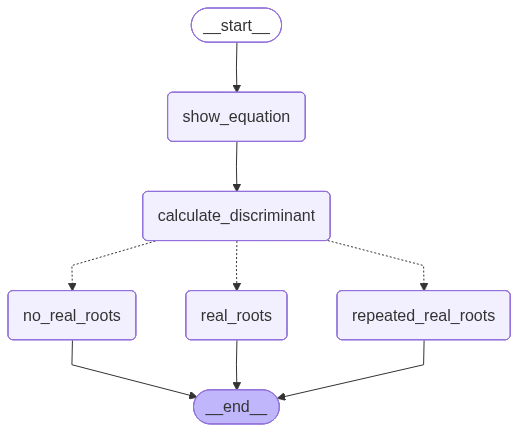

In [41]:
workflow

In [42]:
workflow.invoke({
    'a':5,'b':4,'c':5
})

{'a': 5,
 'b': 4,
 'c': 5,
 'equation': '5x**2 + 4x + 5',
 'discriminant': -84,
 'result': 'No real roots'}